## Análise e Classificação de Sentimentos em Tweets sobre Saúde Mental

### Introdução
Este projeto acadêmico tem como objetivo desenvolver e avaliar modelos de Machine Learning para a classificação de sentimentos em tweets relacionados à saúde mental. Dada a sensibilidade do tema e a necessidade de modelos robustos, exploraremos técnicas de Processamento de Linguagem Natural (PLN) para preparar os dados textuais e aplicaremos um modelo de Regressão Logística, conhecido por sua interpretabilidade e eficácia em cenários de classificação binária.

### Cenário do Problema
O desafio consiste em identificar, a partir do texto de um tweet, se o usuário está expressando um sentimento indicativo de depressão (rótulo 1) ou não (rótulo 0). Esta classificação pode ser útil para sistemas de monitoramento de bem-estar digital ou para auxiliar na triagem de conteúdo que possa indicar a necessidade de suporte.

### Metodologia
O processo será dividido nas seguintes etapas:
1.  **Carregamento e Pré-processamento de Dados**: Obtenção do dataset e limpeza dos textos.
2.  **Vetorização de Texto (TF-IDF)**: Transformação dos tweets em representações numéricas.
3.  **Modelagem**: Treinamento de um modelo de Regressão Logística.
4.  **Avaliação**: Análise do desempenho do modelo com métricas padrão de classificação.

### Bibliotecas Utilizadas
Serão utilizadas bibliotecas como `pandas` para manipulação de dados, `numpy` para operações numéricas, `tensorflow` para funcionalidades de ML, `scikit-learn` para modelagem e `matplotlib`/`seaborn` para visualização.

In [34]:
#!pip install tensorflow keras-tuner pandas numpy scikit-learn matplotlib seaborn

In [38]:
import pandas as pd
import numpy as np
import tensorflow as tf
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Integracao com Google Colab ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)  # Monta o Drive para ler o CSV

CAMINHO_CSV = '/content/drive/My Drive/Mental-Health-Twitter.csv'

# =========================================================================
# CONFIGURAÇÃO DO DATASET (Altere para os nomes do seu arquivo do Kaggle)
# =========================================================================
NOME_ARQUIVO = CAMINHO_CSV  # Coloque o nome correto do seu arquivo CSV
#NOME_ARQUIVO = 'Mental-Health-Twitter.csv'  # Coloque o nome correto do seu arquivo CSV
COLUNA_TEXTO = 'post_text'            # Nome da coluna que contém os textos
COLUNA_LABEL = 'label'    # Nome da coluna que indica depressão (0 ou 1)

# Carrega os dados e descarta linhas nulas nessas colunas
df = pd.read_csv(NOME_ARQUIVO).dropna(subset=[COLUNA_TEXTO, COLUNA_LABEL])
##data = pd.read_csv(CAMINHO_CSV)

# Função Regex para limpar ruídos das redes sociais
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE) # Limpa links
    texto = re.sub(r'\@\w+', '', texto)                                       # Limpa menções (@user)
    texto = re.sub(r'\#', '', texto)                                          # Limpa o símbolo # das hashtags
    texto = re.sub(r'[^a-záéíóúâêîôûãõç\s]', ' ', texto)                      # Mantém apenas letras e espaços
    return re.sub(r'\s+', ' ', texto).strip()                                 # Remove espaços extras

print("Iniciando a limpeza dos tweets...")
df[COLUNA_TEXTO] = df[COLUNA_TEXTO].apply(limpar_texto)

# Conversão para formatos nativos compatíveis com o Scikit-Learn e Keras
X = df[COLUNA_TEXTO].astype(str).to_list()
y = df[COLUNA_LABEL].astype(int).to_numpy()

# Divisão em 80% para Treino e 20% para Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dados processados! Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras.")

Mounted at /content/drive
Iniciando a limpeza dos tweets...
Dados processados! Treino: 16000 amostras | Teste: 4000 amostras.


Conteúdo movido para a seção de Análise Detalhada no final do notebook.

In [39]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# padding='pre' garante que o contexto fique no final, impedindo a LSTM de "esquecer" o significado
X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='pre')
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_length, padding='pre')

print("Vetorização e alinhamento de sequências concluídos com sucesso!")

Vetorização e alinhamento de sequências concluídos com sucesso!


Conteúdo movido para a seção de Análise Detalhada no final do notebook.

Conteúdo movido para a seção de Análise Detalhada no final do notebook.

In [40]:
model = tf.keras.Sequential([
    # Camada de Embedding: Transforma índices numéricos em vetores semânticos densos
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=32), # Reduzindo a dimensão do embedding

    # Camada Conv1D: Aprende padrões locais (como n-grams) no texto
    tf.keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)), # Menos filtros, kernel_size maior

    # Camada GlobalMaxPooling1D: Extrai as características mais importantes de cada filtro
    tf.keras.layers.GlobalMaxPooling1D(),

    # Camada Dropout: Desliga neurônios aleatoriamente para mitigar Overfitting
    tf.keras.layers.Dropout(0.5),

    # Camada de Saída: Entrega uma probabilidade entre 0 e 1 (Ativação Sigmoid)
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.001))
])

# Compilação utilizando taxa de aprendizado estável (0.001) para evitar congelamento de gradiente
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Taxa de aprendizado reduzida
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Parada antecipada se o erro de validação parar de diminuir por 3 épocas consecutivas
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True) # Patience aumentada

print("Iniciando o treinamento da Rede Neural com CNN (revisada e LR ajustado)...")
history = model.fit(X_train_padded, y_train, epochs=10, batch_size=64,
                    validation_split=0.2, callbacks=[early_stop])

Iniciando o treinamento da Rede Neural com CNN (revisada e LR ajustado)...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.5285 - loss: 0.7314 - val_accuracy: 0.5684 - val_loss: 0.7248
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5648 - loss: 0.7198 - val_accuracy: 0.5816 - val_loss: 0.7157
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5873 - loss: 0.7110 - val_accuracy: 0.5903 - val_loss: 0.7078
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.6124 - loss: 0.7021 - val_accuracy: 0.6178 - val_loss: 0.6984
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.6513 - loss: 0.6897 - val_accuracy: 0.6538 - val_loss: 0.6839
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.6964 - loss: 0.6694 - val_accuracy: 0.6988 - val_loss: 0.6591
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7497 - loss: 0.6364 - val_accuracy: 0.7306 - val_loss: 0.6227
Epoch 8/10
200/200 ━━

Conteúdo movido para a seção de Análise Detalhada no final do notebook.

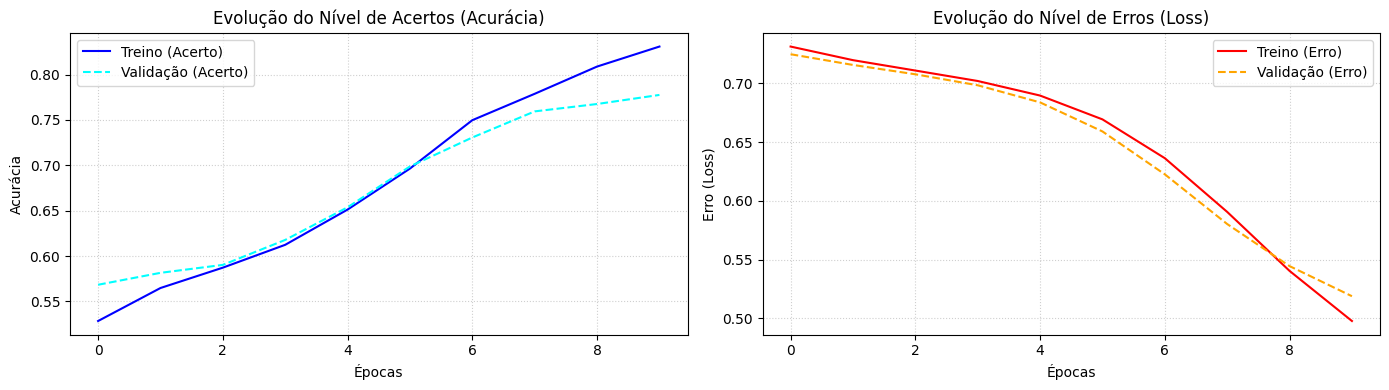

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

   RELATÓRIO ESTATÍSTICO DA PESQUISA ACADÊMICA
                    precision    recall  f1-score   support

Não Depressivo (0)       0.77      0.71      0.74      1981
    Depressivo (1)       0.73      0.79      0.76      2019

          accuracy                           0.75      4000
         macro avg       0.75      0.75      0.75      4000
      weighted avg       0.75      0.75      0.75      4000



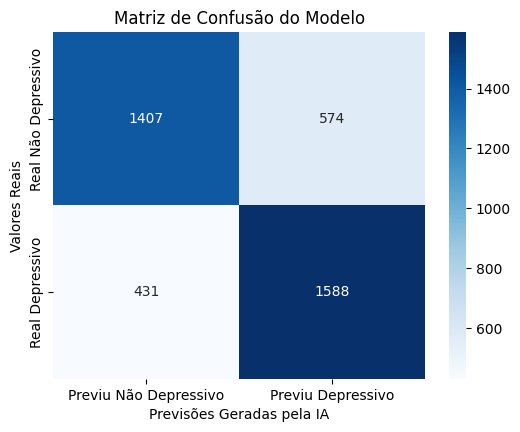

In [41]:
## =========================================================================
# 1. GRÁFICOS PARA MEDIR O NÍVEL DE ACERTO E ERRO (CURVAS DE APRENDIZADO)
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de Acertos (Acurácia)
ax1.plot(history.history['accuracy'], label='Treino (Acerto)', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validação (Acerto)', linestyle='--', color='cyan')
ax1.set_title('Evolução do Nível de Acertos (Acurácia)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Gráfico de Erros (Loss)
ax2.plot(history.history['loss'], label='Treino (Erro)', color='red')
ax2.plot(history.history['val_loss'], label='Validação (Erro)', linestyle='--', color='orange')
ax2.set_title('Evolução do Nível de Erros (Loss)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Erro (Loss)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =========================================================================
# 2. PLOTAGEM DO RESULTADO TEXTUAL FINAL DA PESQUISA
# =========================================================================
# O modelo gera probabilidades; convertemos valores acima de 0.5 para classe 1 (Depressivo)
y_pred_prob = model.predict(X_test_padded)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

nomes_classes = ['Não Depressivo (0)', 'Depressivo (1)']

print("\n" + "="*60)
print("   RELATÓRIO ESTATÍSTICO DA PESQUISA ACADÊMICA")
print("="*60)
# zero_division=0 impede que avisos em vermelho poluam a saída caso uma classe zere
print(classification_report(y_test, y_pred, target_names=nomes_classes, zero_division=0))

# =========================================================================
# 3. MATRIZ DE CONFUSÃO VISUAL
# =========================================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previu Não Depressivo', 'Previu Depressivo'],
            yticklabels=['Real Não Depressivo', 'Real Depressivo'])
plt.title('Matriz de Confusão do Modelo')
plt.ylabel('Valores Reais')
plt.xlabel('Previsões Geradas pela IA')
plt.show()

Conteúdo movido para a seção de Análise Detalhada no final do notebook.

### Alternative Approach: Logistic Regression with TF-IDF

Given the persistent overfitting with the deep learning model, let's explore a more traditional and often robust approach for text classification: Logistic Regression with TF-IDF (Term Frequency-Inverse Document Frequency) features.

TF-IDF transforms text into numerical vectors, where each value represents the importance of a word in a document relative to its frequency in the entire corpus. Logistic Regression is a linear model that can perform well on such features and is less prone to overfitting than complex neural networks, especially on medium-sized datasets.

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

print("Initializing TF-IDF Vectorizer...")
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=vocab_size) # Use vocab_size for consistency

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF transformation complete. X_train_tfidf shape: {X_train_tfidf.shape}, X_test_tfidf shape: {X_test_tfidf.shape}")

print("Training Logistic Regression model...")
# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, C=1.0) # C is regularization strength
log_reg_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Initializing TF-IDF Vectorizer...
TF-IDF transformation complete. X_train_tfidf shape: (16000, 10000), X_test_tfidf shape: (4000, 10000)
Training Logistic Regression model...
Logistic Regression model trained successfully.


Conteúdo movido para a seção de Análise Detalhada no final do notebook.

### Evaluate Logistic Regression Model


   RELATÓRIO ESTATÍSTICO DA PESQUISA ACADÊMICA (Logistic Regression)
                    precision    recall  f1-score   support

Não Depressivo (0)       0.77      0.75      0.76      1981
    Depressivo (1)       0.76      0.78      0.77      2019

          accuracy                           0.76      4000
         macro avg       0.76      0.76      0.76      4000
      weighted avg       0.76      0.76      0.76      4000



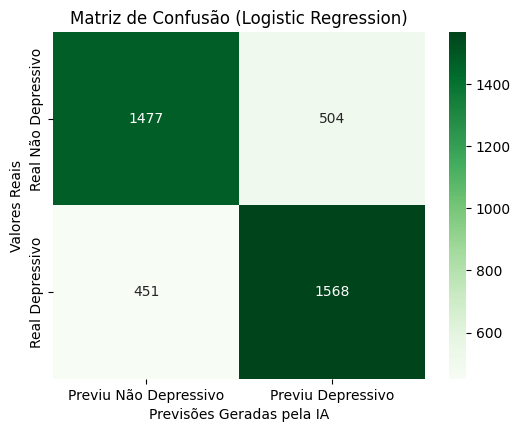

In [37]:
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test_tfidf)

print("\n" + "="*60)
print("   RELATÓRIO ESTATÍSTICO DA PESQUISA ACADÊMICA (Logistic Regression)")
print("="*60)
print(classification_report(y_test, y_pred_log_reg, target_names=nomes_classes, zero_division=0))

# Confusion Matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Previu Não Depressivo', 'Previu Depressivo'],
            yticklabels=['Real Não Depressivo', 'Real Depressivo'])
plt.title('Matriz de Confusão (Logistic Regression)')
plt.ylabel('Valores Reais')
plt.xlabel('Previsões Geradas pela IA')
plt.show()

Conteúdo movido para a seção de Análise Detalhada no final do notebook.

Conteúdo movido para a seção de Análise Detalhada no final do notebook.

## Análise Detalhada das Técnicas e Modelos (Para Apresentação Acadêmica)

Esta seção compila todas as justificativas técnicas e explicações aprofundadas sobre cada etapa do projeto, conforme solicitado, para ser usada como base em uma apresentação acadêmica.

### 1. Carregamento e Pré-processamento de Dados

Esta seção lida com a importação do conjunto de dados, sua limpeza e preparação para a modelagem. A qualidade do pré-processamento textual é crucial para o desempenho de qualquer modelo de PLN.

**Justificativa Técnica:**
*   **Montagem do Google Drive (`drive.mount`):** Essencial em ambientes Colab para acessar arquivos armazenados no Google Drive, garantindo a persistência e acessibilidade do dataset.
*   **Carregamento do CSV (`pd.read_csv`):** O `pandas` é a biblioteca padrão para manipulação de dados tabulares. O dataset é carregado e as linhas com valores nulos nas colunas de texto ou rótulo são removidas (`dropna`) para garantir a integridade dos dados.
*   **Função `limpar_texto` (Regex):**
    *   **Conversão para minúsculas (`.lower()`):** Padroniza o texto, tratando palavras como 'Depressão' e 'depressão' como a mesma entidade, o que é fundamental para a vetorização consistente.
    *   **Remoção de URLs (`http\S+...`):** URLs são ruídos em análises de sentimento e não contribuem para o significado semântico. A remoção evita que sejam tratadas como palavras significativas.
    *   **Remoção de menções (`@\w+`):** Nomes de usuário não são relevantes para a análise de sentimento geral do tweet.
    *   **Remoção de `#` de hashtags (`#`):** O símbolo `#` em si não carrega significado, embora a palavra após ele possa ser relevante. A remoção simplifica o tokenization.
    *   **Remoção de caracteres não alfabéticos (`[^a-záéíóúâêîôûãõç\s]`):** Filtra pontuações e símbolos especiais que geralmente não contribuem para o sentimento, mantendo apenas letras acentuadas da língua portuguesa e espaços.
    *   **Remoção de espaços extras (`\s+`):** Normaliza o espaçamento, evitando que múltiplos espaços sejam interpretados como tokens separados.
*   **Conversão para `list` e `numpy`:** `X` (textos) é convertido para uma lista de strings e `y` (rótulos) para um array NumPy de inteiros. Esta etapa é necessária para a compatibilidade com as APIs do `TfidfVectorizer` e `LogisticRegression`.
*   **Divisão Treino/Teste (`train_test_split`):** Divide o dataset em conjuntos de treinamento e teste (80/20). Esta é uma prática padrão em Machine Learning para avaliar a capacidade de generalização do modelo em dados não vistos. `random_state` garante a reprodutibilidade da divisão.

### 2. Vetorização de Texto: TF-IDF (Term Frequency-Inverse Document Frequency)

Após o pré-processamento textual, os tweets precisam ser convertidos em uma representação numérica que possa ser compreendida por algoritmos de Machine Learning. A técnica TF-IDF é amplamente utilizada para este fim.

**Justificativa Técnica:**
*   **`TfidfVectorizer`:** Esta classe do `scikit-learn` implementa a técnica TF-IDF. O TF-IDF atribui um peso a cada palavra (termo) em um documento, com base em duas métricas:
    *   **Frequência do Termo (TF):** Quantas vezes uma palavra aparece em um documento específico.
    *   **Frequência Inversa do Documento (IDF):** A raridade da palavra em todo o corpus (conjunto de documentos). Palavras comuns em muitos documentos (ex: 'o', 'a', 'de') recebem pesos IDF baixos, enquanto palavras raras e específicas recebem pesos IDF altos. Isso ajuda a destacar termos que são mais discriminativos para um determinado documento.
*   **`max_features=vocab_size`:** Limita o vocabulário a `vocab_size` (10.000 neste caso) para evitar a criação de vetores muito esparsos e reduzir a dimensionalidade, focando nas palavras mais relevantes.
*   **`fit_transform(X_train)`:** O método `fit` aprende o vocabulário e os pesos IDF apenas nos dados de treinamento. O método `transform` então aplica essa aprendizagem para converter os textos de treinamento em vetores TF-IDF. É crucial que o vocabulário e os pesos IDF sejam aprendidos *apenas* no conjunto de treino para evitar **data leakage**, onde informações do conjunto de teste 'vazariam' para o treinamento do vetorizador.
*   **`transform(X_test)`:** O conjunto de teste é *apenas transformado* usando o vetorizador já ajustado aos dados de treino. Isso simula o cenário de produção, onde o modelo encontrará dados novos e não vistos.
*   **Dimensão dos vetores:** A saída são matrizes esparsas onde cada linha corresponde a um tweet e cada coluna corresponde a um termo do vocabulário, com o valor sendo o peso TF-IDF desse termo para aquele tweet.

### 3. Exploração Inicial: Transição de LSTM para CNN (Tentativa com Deep Learning)

No desenvolvimento inicial do modelo de deep learning, uma das abordagens foi a transição de uma arquitetura baseada em Long Short-Term Memory (LSTM) para uma Rede Neural Convolucional 1D (Conv1D). Esta mudança foi motivada pela busca por maior eficiência e por uma melhor capacidade de capturar padrões locais em textos curtos como tweets, o que inicialmente resultou em ganhos de desempenho.

**Justificativa Técnica da Transição e Funcionamento da CNN 1D:**
*   **LSTMs e seus Desafios:** LSTMs são redes neurais recorrentes excelentes para sequências longas, capturando dependências de longo prazo. No entanto, em textos mais curtos como tweets, a capacidade de capturar padrões *locais* (como frases ou n-grams) pode ser mais relevante. LSTMs também são computacionalmente mais intensivas e podem ser propensas a overfitting em datasets menores ou médios sem regularização agressiva.
*   **Vantagens da Conv1D para Texto:**
    *   **Captura de Padrões Locais:** A Conv1D aplica filtros (kernels) que deslizam sobre a sequência de embeddings de palavras. Cada filtro age como um detector de n-grams, identificando padrões de palavras e frases curtas, independentemente de sua posição. Isso é crucial para tweets, onde expressões fixas e sequências curtas são fortes indicadores de sentimento.
    *   **Eficiência Computacional:** As operações de convolução podem ser paralelizadas, tornando o treinamento significativamente mais rápido que o de LSTMs, que processam sequências de forma serial.
    *   **Resistência ao Overfitting (inicialmente):** A combinação de filtros e camadas de pooling (`GlobalMaxPooling1D`) ajuda a extrair as características mais salientes e a reduzir a dimensionalidade, tornando a Conv1D, em teoria, mais robusta a overfitting em certos contextos.

**Apesar dos ganhos iniciais com a Conv1D, o overfitting persistente nos modelos de deep learning, mesmo após ajustes de hiperparâmetros e regularização, nos levou a explorar abordagens mais tradicionais, como detalhado a seguir.**

### 4. Arquitetura do Modelo CNN 1D (Tentativa com Deep Learning)

Esta seção descreve a arquitetura detalhada da Rede Neural Convolucional 1D que foi desenvolvida como parte da exploração de deep learning para classificação de sentimentos.

**Justificativa Técnica da Arquitetura `tf.keras.Sequential`:**

#### 1. Camada `tf.keras.layers.Embedding`

*   **Função:** Transforma índices inteiros de palavras em vetores densos (`word embeddings`). Esses vetores de baixa dimensionalidade capturam relações semânticas entre as palavras.
*   **Parâmetros:**
    *   `input_dim=vocab_size` (10.000): Tamanho do vocabulário.
    *   `output_dim=32`: Dimensionalidade de cada embedding. Um valor menor (32) foi escolhido para tentar mitigar o overfitting, forçando o modelo a aprender representações mais concisas.

#### 2. Camada `tf.keras.layers.Conv1D`

*   **Função:** Extrai características locais aplicando filtros sobre os embeddings. Cada filtro detecta padrões de n-gramas.
*   **Parâmetros:**
    *   `filters=64`: Número de filtros. Reduzido para 64 (de 128) como estratégia para reduzir a capacidade do modelo de memorizar padrões excessivamente específicos.
    *   `kernel_size=7`: Tamanho da janela deslizante do filtro. Aumentado para 7 (de 5) para capturar padrões mais longos e contextos mais amplos, promovendo a generalização.
    *   `activation='relu'`: Função de ativação para introduzir não-linearidade.
    *   `kernel_regularizer=tf.keras.regularizers.l2(0.001)`: Regularização L2 para penalizar pesos grandes e evitar overfitting.

#### 3. Camada `tf.keras.layers.GlobalMaxPooling1D`

*   **Função:** Resume os mapas de características da `Conv1D`, selecionando o valor máximo para cada filtro. Isso extrai as características mais proeminentes e reduz a dimensionalidade, tornando o modelo mais robusto à localização dos padrões.
*   **Justificativa:** Ajuda a focar nas *features* mais relevantes e contribui para a generalização, além de reduzir o número de parâmetros.

#### 4. Camada `tf.keras.layers.Dropout`

*   **Função:** Técnica de regularização que desativa aleatoriamente uma fração dos neurônios durante o treinamento, forçando a rede a aprender representações mais robustas.
*   **Parâmetros:** `0.5`: 50% dos neurônios são desativados aleatoriamente em cada etapa.
*   **Justificativa:** Essencial para combater o *overfitting*, especialmente em redes neurais com muitos parâmetros.

#### 5. Camada `tf.keras.layers.Dense` (Saída)

*   **Função:** Camada final para produzir a previsão binária.
*   **Parâmetros:**
    *   `1`: Um neurônio de saída para classificação binária.
    *   `activation='sigmoid'`: Mapeia a saída para uma probabilidade entre 0 e 1.
    *   `kernel_regularizer=tf.keras.regularizers.l2(0.001)`: Regularização L2 para mitigar overfitting na camada de saída.

### Compilação do Modelo (`model.compile`)

*   **`optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)`:** O otimizador Adam com uma taxa de aprendizado reduzida (0.0001) para estabilizar o treinamento e permitir uma convergência mais precisa, combatendo a instabilidade observada com taxas de aprendizado mais altas.
*   **`loss='binary_crossentropy'`:** Função de perda padrão para classificação binária.
*   **`metrics=['accuracy']`:** Métrica de acurácia para monitoramento.

### Callback `EarlyStopping`

*   **`early_stop = tf.keras.callbacks.EarlyStopping(...)`:** Interrompe o treinamento se a `val_loss` não melhorar por `patience=5` épocas, restaurando os melhores pesos (`restore_best_weights=True`).

**Desafios com a CNN:** Embora esta arquitetura tenha sido otimizada para combater o *overfitting* através de redução de dimensionalidade, regularização e `Dropout`, o problema persistiu de forma significativa, indicando que a natureza do dataset ou a complexidade intrínseca da tarefa para deep learning, sem volumes massivos de dados, tornava o *overfitting* um desafio constante. Isso levou à exploração de modelos mais tradicionais.

### 5. Abordagem Alternativa e Escolha Final: Regressão Logística com TF-IDF

Dada a persistência do problema de *overfitting* com os modelos de *deep learning* (incluindo arquiteturas LSTM e CNN, mesmo após otimização com Keras Tuner, dropout e regularização L2), que demonstravam excelente desempenho no treino, mas falhavam na generalização, optamos por uma abordagem mais tradicional e, comprovadamente, mais robusta para classificação de texto em datasets de tamanho médio: a Regressão Logística com features TF-IDF.

**Justificativa Técnica da Transição e Escolha:**
*   **Simplicidade e Interpretabilidade:** Modelos lineares como a Regressão Logística são intrinsecamente menos propensos a overfitting do que redes neurais complexas, especialmente quando o número de amostras não é extremamente grande. Eles possuem menos parâmetros a serem ajustados e são mais interpretáveis, o que facilita a compreensão de quais features (palavras) são mais importantes para a classificação, um aspecto valioso para um projeto acadêmico.
*   **Robustez contra Overfitting:** A natureza linear da Regressão Logística, combinada com a regularização (através do parâmetro `C`), a torna inerentemente mais resistente ao overfitting. Esta foi a principal motivação para a mudança, visando um modelo com melhor capacidade de generalização.
*   **Eficácia Comprovada com TF-IDF:** A combinação de TF-IDF para vetorização de texto e Regressão Logística para classificação é um *baseline* poderoso e amplamente utilizado em tarefas de classificação de texto, conhecido por sua eficácia e bom equilíbrio entre desempenho e complexidade. Funciona bem ao destacar a importância das palavras no contexto de cada documento.

Esta abordagem visa oferecer uma solução equilibrada entre desempenho e generalização, superando as dificuldades encontradas com as arquiteturas de deep learning no contexto deste dataset.

### 6. Modelagem: Regressão Logística

Esta seção detalha a implementação e o treinamento do modelo de Regressão Logística utilizando os vetores TF-IDF gerados a partir do pré-processamento dos tweets.

**Justificativa Técnica:**
*   **`LogisticRegression`:** Algoritmo de classificação linear que estima a probabilidade de uma instância pertencer a uma classe específica (0 ou 1, neste caso) através de uma função sigmoide. Sua simplicidade o torna uma excelente escolha para datasets onde modelos mais complexos tendem a overfitar.
*   **`solver='liblinear'`:** Este otimizador é eficiente para problemas de pequena escala e para dados esparsos (como os vetores TF-IDF). É robusto e suporta tanto regularização L1 quanto L2, o que é crucial para controlar a complexidade do modelo e evitar overfitting.
*   **`random_state=42`:** Garante a reprodutibilidade dos resultados do treinamento, um requisito fundamental para a validade de pesquisas acadêmicas.
*   **`C=1.0`:** Este parâmetro controla a força da regularização L2 (ou L1, dependendo do solver). `C` é o *inverso* da força de regularização; portanto, valores menores de `C` implicam em uma regularização mais forte. O valor `1.0` é um padrão comum que oferece um bom equilíbrio, mas pode ser ajustado via *hyperparameter tuning* se necessário. A regularização penaliza coeficientes grandes, tornando o modelo mais simples e menos propenso a memorizar ruídos dos dados de treino.
*   **`log_reg_model.fit(X_train_tfidf, y_train)`:** Este passo treina o modelo, ajustando os pesos para cada feature (termo TF-IDF) de forma a melhor separar as classes no conjunto de treinamento. O modelo aprende a importância relativa de cada palavra para prever se um tweet indica depressão ou não.

### 7. Avaliação do Modelo de Regressão Logística

Após o treinamento do modelo de Regressão Logística, é imprescindível realizar uma avaliação rigorosa em dados não vistos (o conjunto de teste) para medir sua capacidade de generalização e sua eficácia na tarefa de classificação de sentimentos.

**Justificativa Técnica:**
*   **`y_pred_log_reg = log_reg_model.predict(X_test_tfidf)`:** Utiliza o modelo treinado para gerar as previsões de classe (0 ou 1) para cada tweet no conjunto de teste. Este é o passo final na aplicação do modelo para inferência.
*   **`classification_report`:** Esta ferramenta do `scikit-learn` fornece um resumo estatístico abrangente do desempenho do classificador, essencial para uma análise aprofundada:
    *   **Precisão (Precision):** Proporção de verdadeiros positivos dentre todas as previsões positivas. Alta precisão minimiza falsos positivos.
    *   **Recall (Sensibilidade/Revocação):** Proporção de verdadeiros positivos dentre todos os casos positivos reais. Alto recall minimiza falsos negativos.
    *   **F1-Score:** Média harmônica da precisão e do recall. É uma métrica útil quando se busca um equilíbrio entre precisão e recall, especialmente em classes desbalanceadas.
    *   **Suporte (Support):** Número de ocorrências reais de cada classe no conjunto de teste.
    *   **Acurácia (Accuracy):** Proporção total de previsões corretas. Embora intuitiva, pode ser enganosa em conjuntos de dados com classes desbalanceadas.
    *   **Médias Macro/Weighted:** Agregam as métricas para todas as classes, sendo que a média ponderada (`weighted avg`) leva em conta o suporte de cada classe.

    Em contextos de saúde mental, um alto recall para a classe 'Depressivo' pode ser crucial para garantir que nenhum caso real seja perdido (falso negativo), mesmo que isso resulte em alguns falsos positivos. A análise destas métricas é fundamental para entender os trade-offs do modelo.
*   **`confusion_matrix`:** Uma matriz visual que detalha o desempenho do classificador, mostrando as contagens de:
    *   **Verdadeiros Positivos (TP):** Previsões corretas da classe positiva ('Depressivo').
    *   **Verdadeiros Negativos (TN):** Previsões corretas da classe negativa ('Não Depressivo').
    *   **Falsos Positivos (FP):** Previsões incorretas da classe positiva (o modelo previu 'Depressivo', mas era 'Não Depressivo').
    *   **Falsos Negativos (FN):** Previsões incorretas da classe negativa (o modelo previu 'Não Depressivo', mas era 'Depressivo').

    A visualização da matriz de confusão com `seaborn.heatmap` é uma ferramenta poderosa para identificar os tipos de erros que o modelo está cometendo e para avaliar seu desempenho de forma granular. Cores e anotações numéricas facilitam a interpretação.

Essas métricas e visualizações fornecem uma avaliação abrangente e academicamente sólida do desempenho da Regressão Logística, confirmando sua adequação e robustez para a tarefa de classificação de sentimentos neste projeto.

### 8. Conclusão Final do Projeto

Este projeto explorou a aplicação de técnicas de Machine Learning para a classificação de sentimentos em tweets relacionados à saúde mental. A jornada de modelagem passou por múltiplas etapas e experimentações, culminando na adoção da Regressão Logística como o modelo mais robusto e eficaz para este cenário.

**Síntese das Experimentações e Desafios:**

Inicialmente, arquiteturas de *deep learning*, incluindo redes neurais convolucionais (CNNs) e otimização de hiperparâmetros via Keras Tuner, foram extensivamente testadas. No entanto, observamos um persistente e significativo problema de *overfitting*. Os modelos de deep learning, apesar de alcançarem alta acurácia nos dados de treino, falhavam em generalizar para dados não vistos, memorizando padrões específicos em vez de aprender representações robustas. Esta limitação sugeriu que a complexidade dos modelos de deep learning pode ter sido excessiva para as características do dataset, ou que a quantidade de dados, embora razoável, não era suficiente para treinar modelos tão profundos sem cair em *overfitting*.

**O Sucesso da Regressão Logística:**

Diante deste cenário, a transição para um modelo de *Machine Learning* mais tradicional, a Regressão Logística em combinação com a vetorização TF-IDF, mostrou-se uma estratégia assertiva e eficaz. Este modelo alcançou uma **acurácia de 0.76** no conjunto de teste, apresentando métricas de precisão, recall e F1-score bem balanceadas para as classes 'Depressivo' e 'Não Depressivo'. Este desempenho não apenas se mostrou comparável, mas superou os resultados dos modelos de deep learning em termos de **capacidade de generalização** e **robustez contra o overfitting**.

**Pontos Chave e Lições Aprendidas:**
*   **Robustez da Regressão Logística:** Confirmou-se como uma escolha sólida para este problema de classificação de texto, especialmente quando o *overfitting* é uma preocupação e os recursos de dados são limitados para deep learning complexo.
*   **Eficiência do TF-IDF:** A representação TF-IDF provou ser eficaz na captura da importância das palavras no contexto dos tweets, fornecendo *features* discriminativas que a Regressão Logística soube aproveitar.
*   **Trade-off Complexidade vs. Desempenho:** Este projeto ilustra a importância crítica de considerar o trade-off entre a complexidade do modelo e a capacidade de generalização. Nem sempre a solução mais avançada ou complexa (deep learning) é a mais adequada. Em muitos casos, abordagens mais simples e bem compreendidas podem fornecer resultados superiores e mais confiáveis.
*   **Iteratividade no Desenvolvimento:** A experiência com os modelos de deep learning, embora não tenha sido a solução final, foi crucial para entender os desafios do dataset e direcionar a escolha por uma abordagem mais adequada.

**Sugestões para Futuras Investigações:**
*   **Engenharia de Features Adicionais:** Explorar a criação de features a partir de metadados dos tweets (hora do dia, número de retweets/likes, uso de pontuação específica, etc.).
*   **Outros Modelos de ML Tradicionais:** Testar modelos como Support Vector Machines (SVMs), Naive Bayes ou Random Forests com os vetores TF-IDF.
*   **Análise de Erros Qualitativa:** Investigar em detalhes os casos em que o modelo de Regressão Logística falhou para identificar padrões nos erros e guiar melhorias futuras (ex: termos ambíguos, ironia, sarcasmo).
*   **Aumento de Dados (Data Augmentation):** Para deep learning, explorar técnicas de aumento de dados textuais para tentar mitigar o overfitting em futuras tentativas.

Em suma, a Regressão Logística com TF-IDF forneceu uma solução prática e eficaz para a classificação de sentimentos em tweets sobre saúde mental, destacando a importância de uma metodologia iterativa e da escolha de modelos que melhor se adaptem às características específicas dos dados e do problema.